In [1]:
!pip install -q kagglehub xgboost lightgbm shap

import kagglehub, os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix)
from sklearn.ensemble           import RandomForestClassifier
from sklearn.linear_model       import LogisticRegression

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# DL
import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils     import to_categorical

# SHAP
import shap

print("✅ All libraries imported!")
print(f"   TensorFlow : {tf.__version__}")

✅ All libraries imported!
   TensorFlow : 2.20.0


In [2]:
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
print(" Path:", path)

for root, _, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

 Path: /kaggle/input/datasets/atharvaingle/crop-recommendation-dataset
/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv


In [3]:
csv_path = os.path.join(path, "Crop_recommendation.csv")
df = pd.read_csv(csv_path)

print("Shape :", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget crops:")
print(df['label'].value_counts())
df.head()

Shape : (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Target crops:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:

print(df.info())


print(df.isnull().sum())


print(df.describe().round(2))

print(f"\nTotal unique crops : {df['label'].nunique()}")
print(f"Crops              : {df['label'].unique().tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
             N        P        K  temperature  humidity       ph  rainfall
count  2200.00  2200.00  2200.00      2200.00   2200.00  2200.00   2200.00
mean     50.55    53.36    48.15        25.62     71.48     6.47    103.46
std      36.92    32.99    50.6

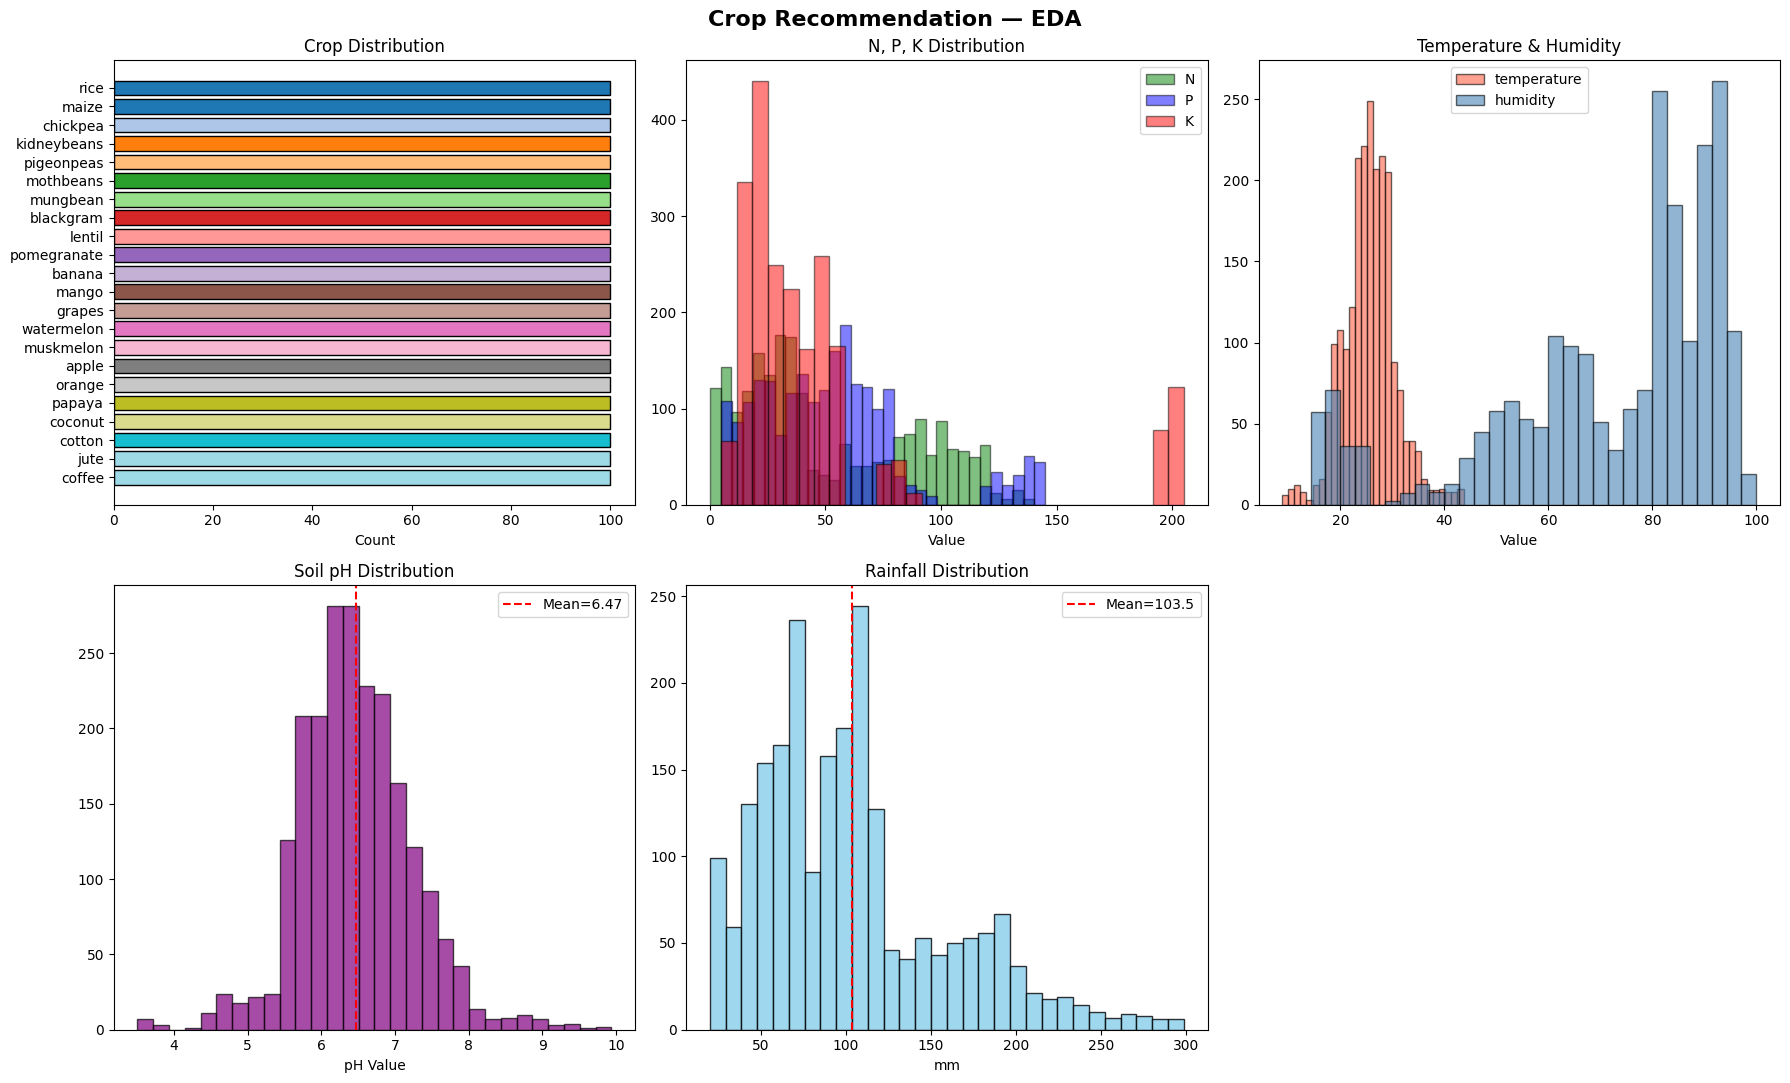

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Crop Recommendation — EDA', fontsize=16, fontweight='bold')

# 5a. Crop distribution
crop_counts = df['label'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(crop_counts)))
axes[0,0].barh(crop_counts.index, crop_counts.values,
               color=colors, edgecolor='black')
axes[0,0].set_title('Crop Distribution')
axes[0,0].set_xlabel('Count')
axes[0,0].invert_yaxis()

# 5b. N, P, K distribution
features_npk = ['N', 'P', 'K']
for feat, color in zip(features_npk, ['green','blue','red']):
    axes[0,1].hist(df[feat], bins=30, alpha=0.5,
                   color=color, label=feat, edgecolor='black')
axes[0,1].set_title('N, P, K Distribution')
axes[0,1].set_xlabel('Value')
axes[0,1].legend()

# 5c. Temperature & Humidity
for feat, color in zip(['temperature','humidity'], ['tomato','steelblue']):
    axes[0,2].hist(df[feat], bins=30, alpha=0.6,
                   color=color, label=feat, edgecolor='black')
axes[0,2].set_title('Temperature & Humidity')
axes[0,2].set_xlabel('Value')
axes[0,2].legend()

# 5d. pH distribution
axes[1,0].hist(df['ph'], bins=30, color='purple',
               edgecolor='black', alpha=0.7)
axes[1,0].set_title('Soil pH Distribution')
axes[1,0].set_xlabel('pH Value')
axes[1,0].axvline(df['ph'].mean(), color='red',
                  linestyle='--', label=f"Mean={df['ph'].mean():.2f}")
axes[1,0].legend()

# 5e. Rainfall distribution
axes[1,1].hist(df['rainfall'], bins=30, color='skyblue',
               edgecolor='black', alpha=0.8)
axes[1,1].set_title('Rainfall Distribution')
axes[1,1].set_xlabel('mm')
axes[1,1].axvline(df['rainfall'].mean(), color='red',
                  linestyle='--', label=f"Mean={df['rainfall'].mean():.1f}")
axes[1,1].legend()

# 5f. Correlation heatmap
axes[1,2].set_visible(False)

plt.tight_layout()
plt.show()

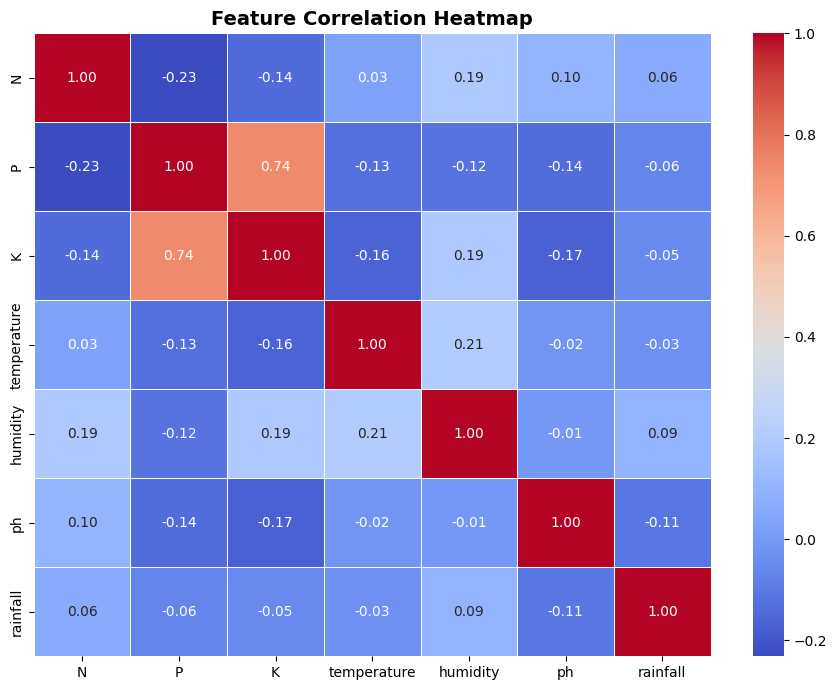

In [6]:
plt.figure(figsize=(9, 7))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

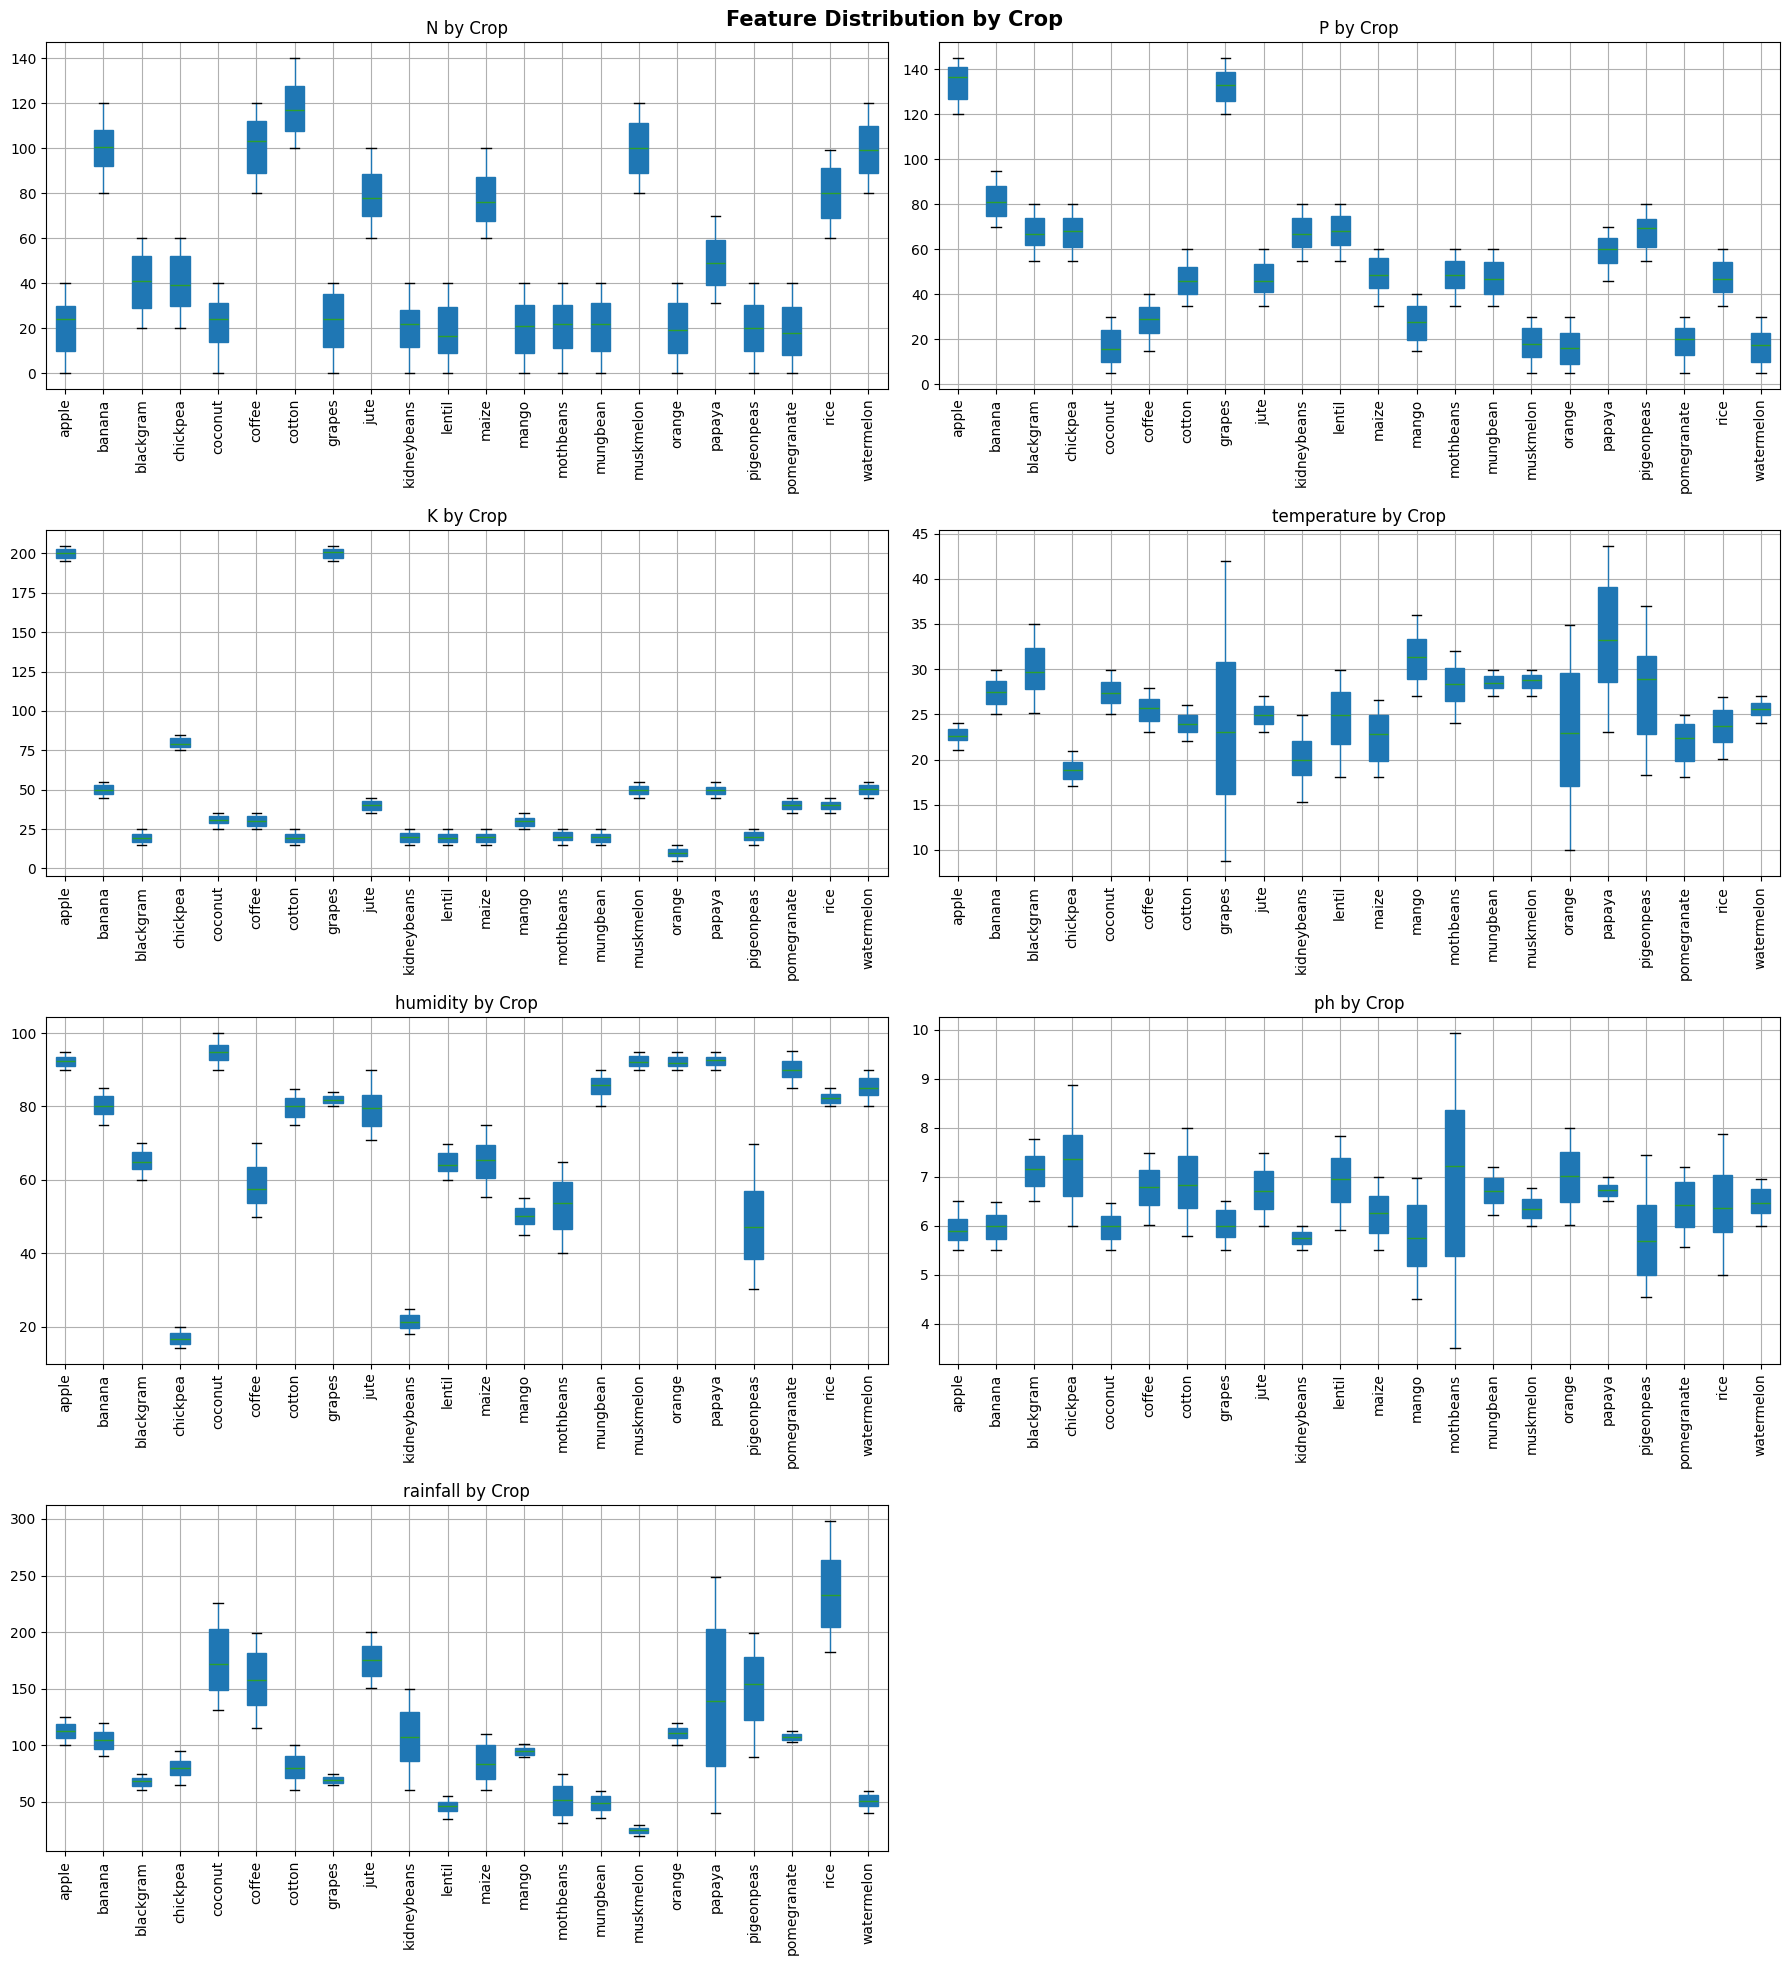

In [7]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.ravel()

for i, feat in enumerate(features):
    crop_order = (df.groupby('label')[feat]
                    .median()
                    .sort_values(ascending=False).index)
    df.boxplot(column=feat, by='label', ax=axes[i],
               rot=90, patch_artist=True)
    axes[i].set_title(f'{feat} by Crop')
    axes[i].set_xlabel('')
    plt.sca(axes[i])
    plt.title(f'{feat} by Crop')

axes[-1].set_visible(False)
plt.suptitle('Feature Distribution by Crop', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

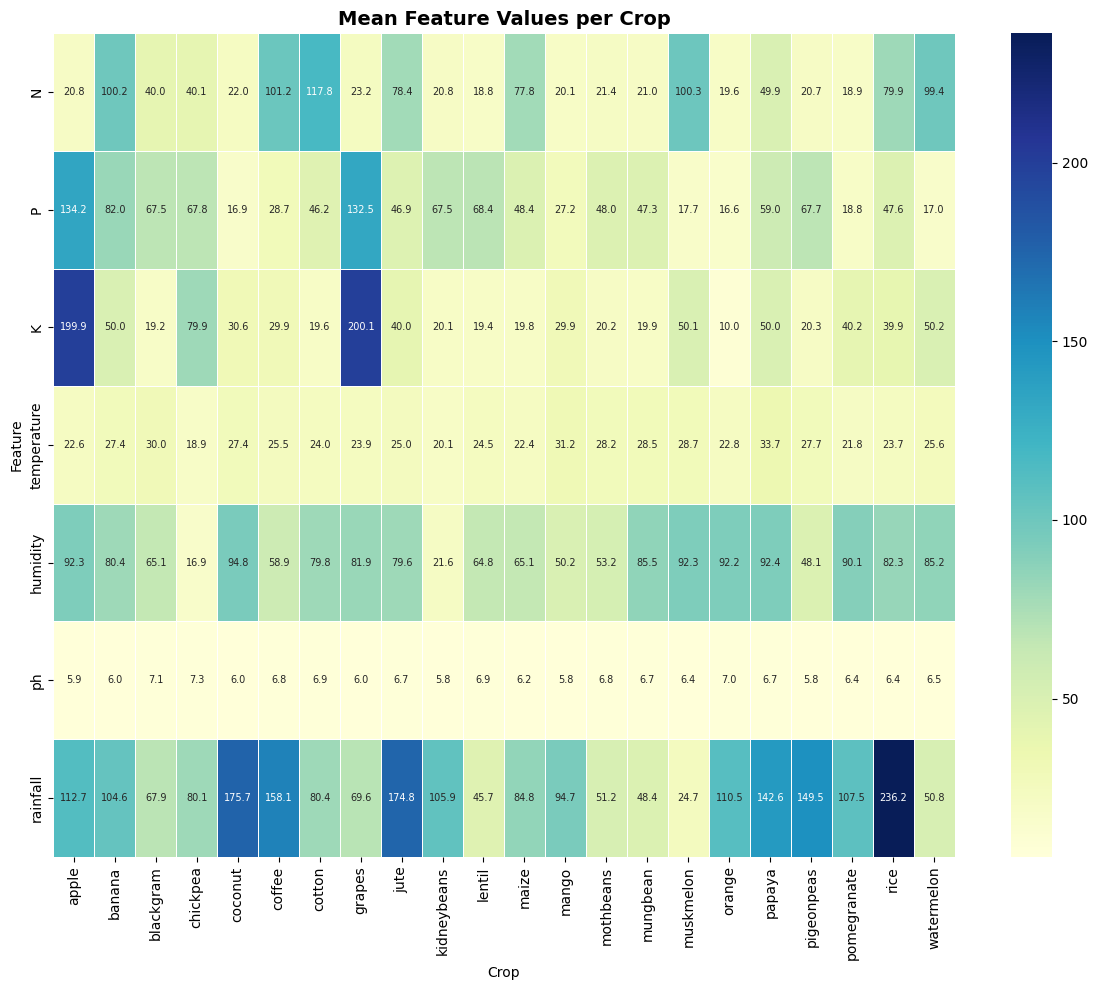

In [8]:
crop_profile = df.groupby('label')[features].mean().round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(crop_profile.T, annot=True, fmt='.1f',
            cmap='YlGnBu', linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Mean Feature Values per Crop',
          fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [9]:
X = df[features].values
y_raw = df['label'].values

# Label Encoding
le = LabelEncoder()
y  = le.fit_transform(y_raw)

NUM_CLASSES = len(le.classes_)
print(f"Features   : {X.shape[1]}")
print(f"Samples    : {X.shape[0]}")
print(f"Num Classes: {NUM_CLASSES}")
print(f"Classes    : {le.classes_.tolist()}")

Features   : 7
Samples    : 2200
Num Classes: 22
Classes    : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

scaler    = StandardScaler()
X_train_sc= scaler.fit_transform(X_train)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print(f"Train : {X_train_sc.shape}")
print(f"Val   : {X_val_sc.shape}")
print(f"Test  : {X_test_sc.shape}")

Train : (1584, 7)
Val   : (176, 7)
Test  : (440, 7)


In [11]:
results = {}

def evaluate(name, model, X_tr, X_te,
             y_tr, y_te, is_nn=False):

    if not is_nn:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        try:
            y_prob = model.predict_proba(X_te)
        except:
            y_prob = None
    else:
        y_prob = model.predict(X_te, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_te, y_pred)
    results[name] = {'Accuracy': round(acc, 4)}

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=le.classes_,
          zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                annot_kws={'size': 7})
    plt.title(f'{name} — Confusion Matrix',
              fontsize=13, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0,  fontsize=7)
    plt.tight_layout()
    plt.show()

    return y_pred, y_prob


  Random Forest
  Accuracy : 0.9977
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00 

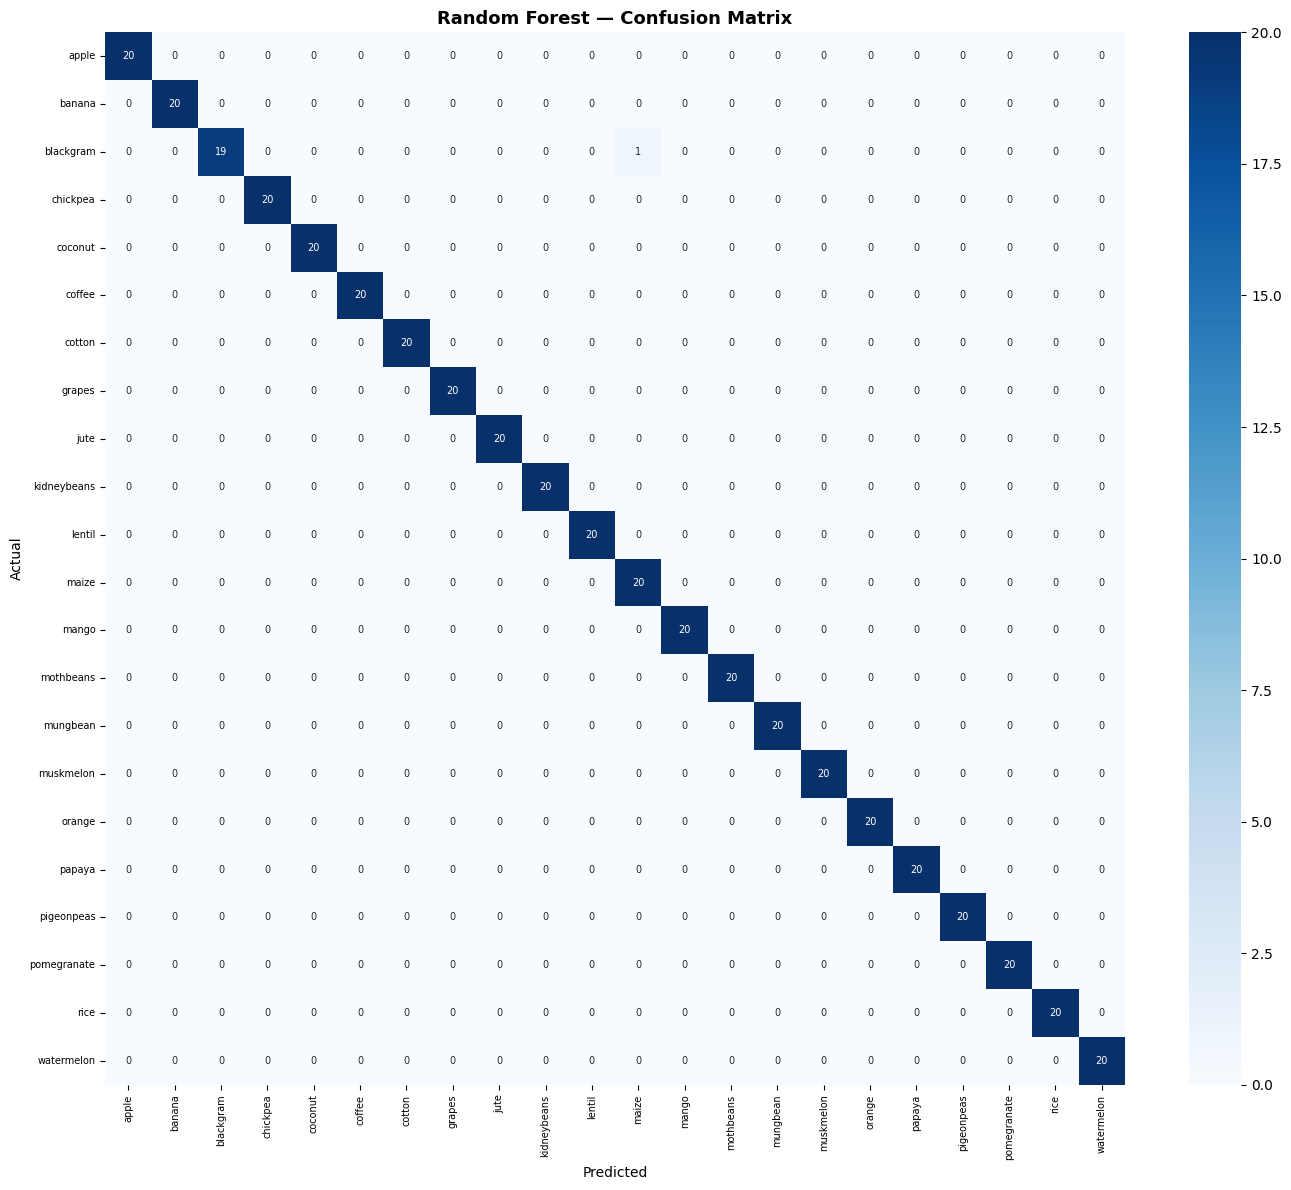

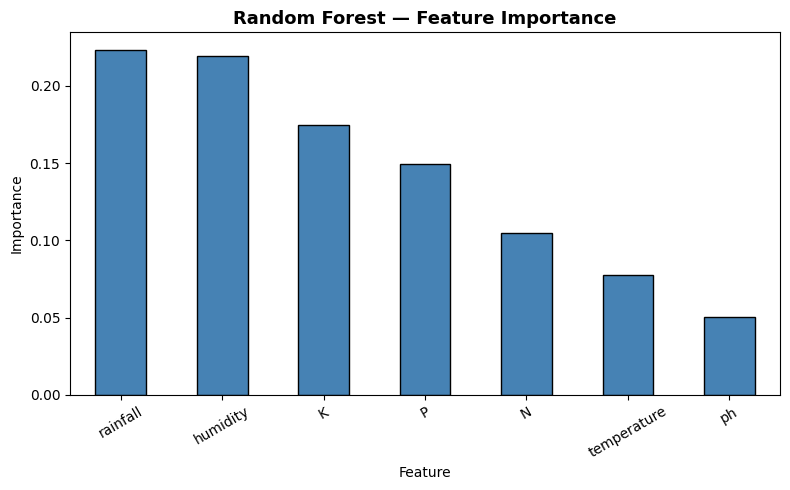

In [12]:
rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,
    random_state = 42,
    n_jobs       = -1
)
rf_pred, rf_prob = evaluate(
    'Random Forest', rf,
    X_train_sc, X_test_sc,
    y_train, y_test
)

# Feature Importance
feat_imp_rf = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp_rf.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


  XGBoost
  Accuracy : 0.9886
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00       

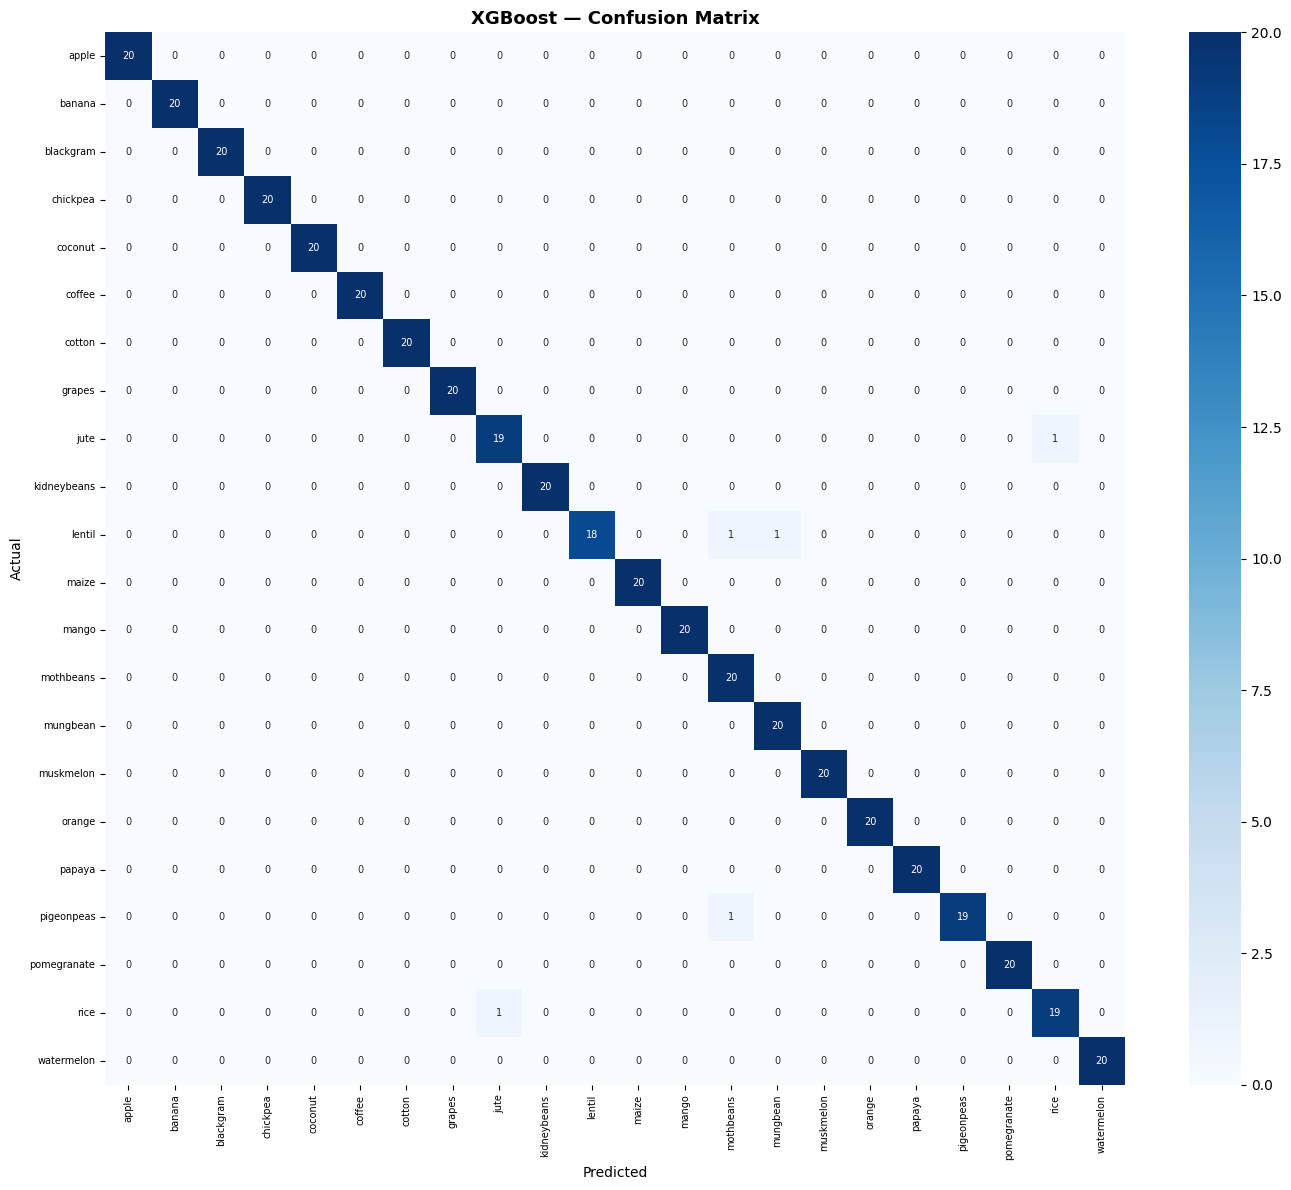

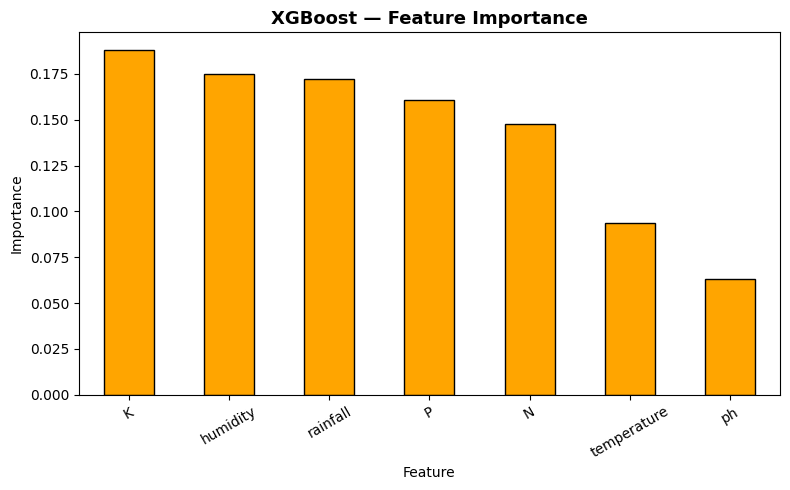

In [13]:
xgb = XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)
xgb_pred, xgb_prob = evaluate(
    'XGBoost', xgb,
    X_train_sc, X_test_sc,
    y_train, y_test
)

# Feature Importance
feat_imp_xgb = pd.Series(
    xgb.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp_xgb.plot(kind='bar', color='orange', edgecolor='black')
plt.title('XGBoost — Feature Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


  LightGBM
  Accuracy : 0.9909
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00      

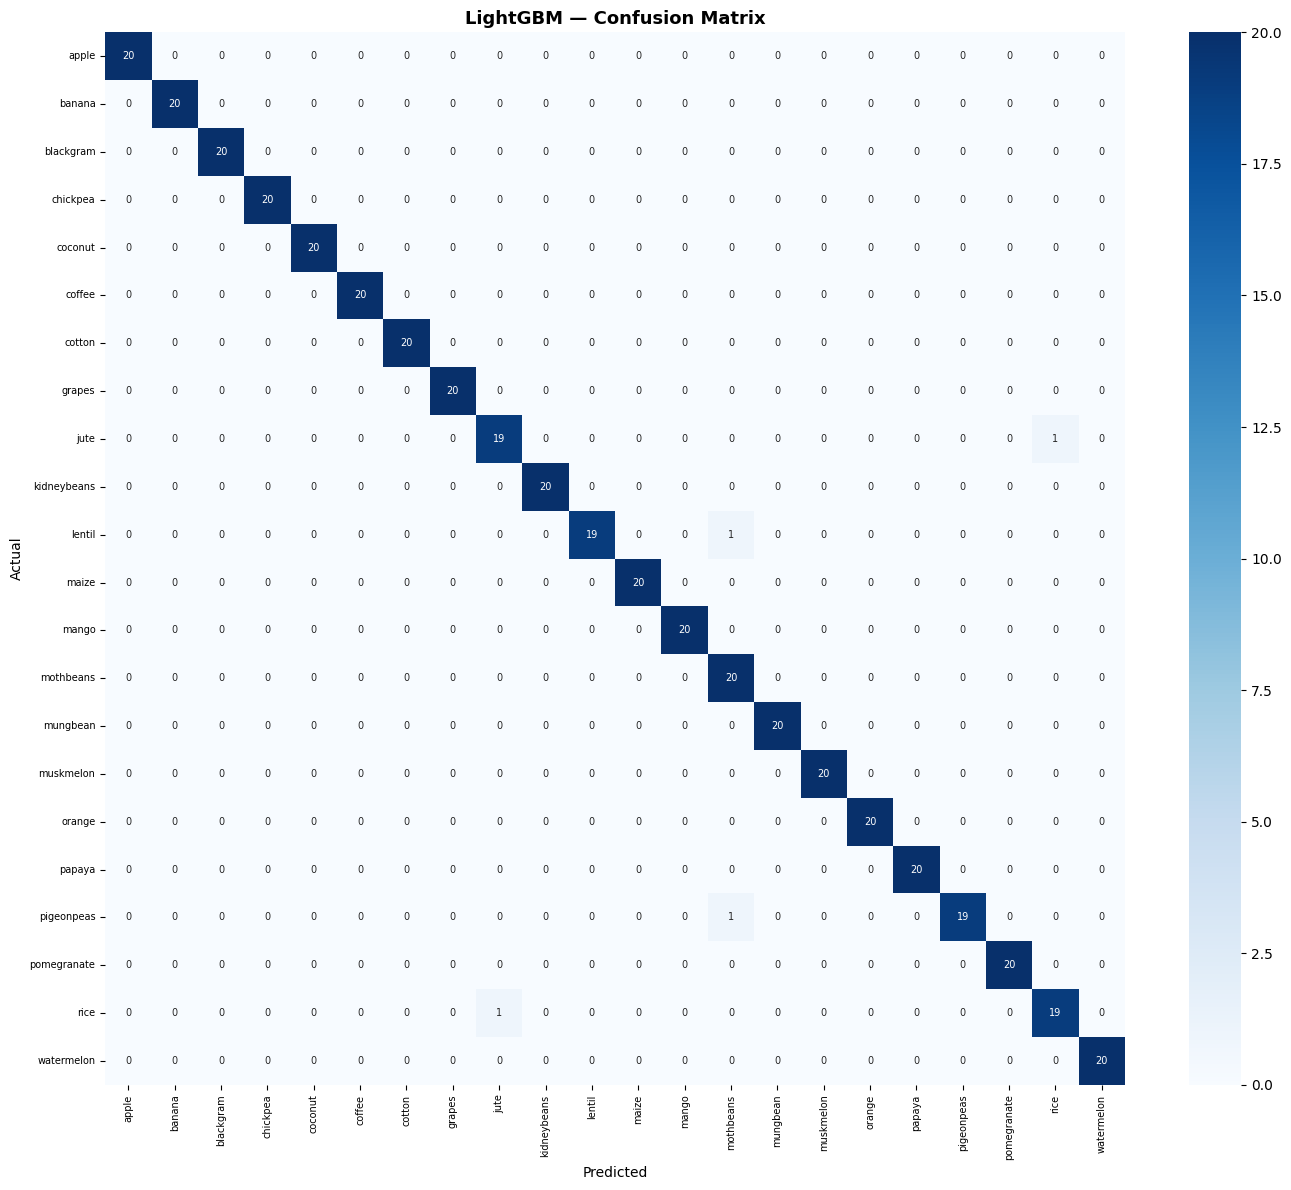

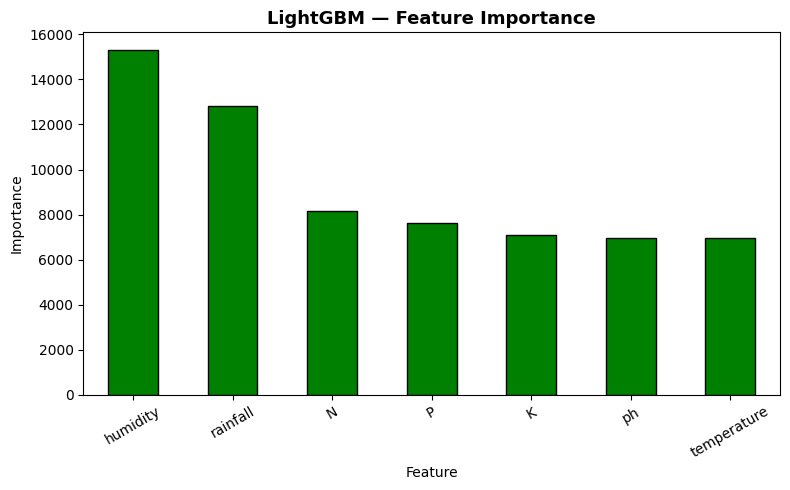

In [14]:
lgb = LGBMClassifier(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 6,
    num_leaves    = 50,
    random_state  = 42,
    verbose       = -1,
    n_jobs        = -1
)
lgb_pred, lgb_prob = evaluate(
    'LightGBM', lgb,
    X_train_sc, X_test_sc,
    y_train, y_test
)

# Feature Importance
feat_imp_lgb = pd.Series(
    lgb.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp_lgb.plot(kind='bar', color='green', edgecolor='black')
plt.title('LightGBM — Feature Importance',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

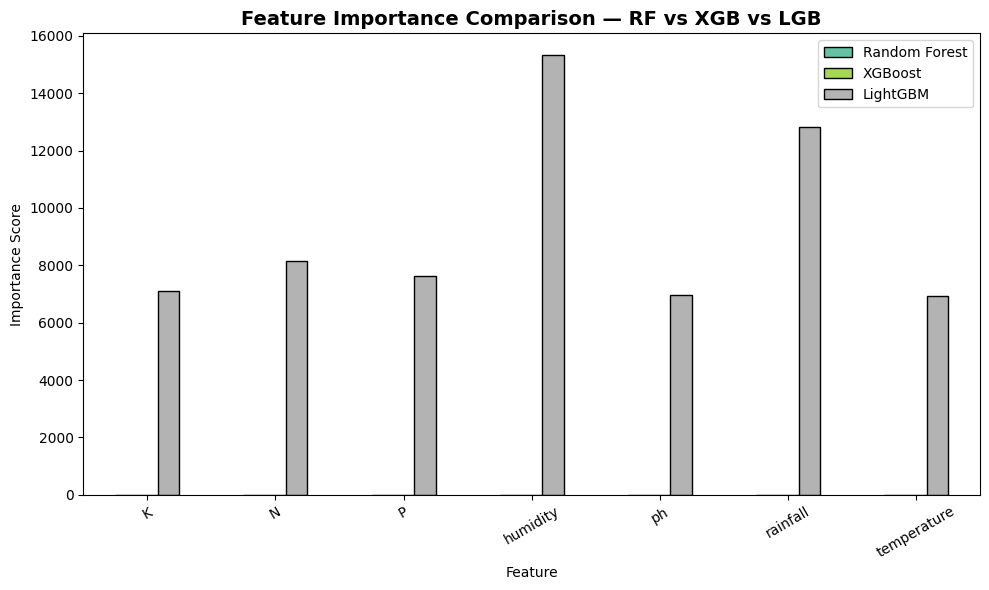

In [15]:
feat_compare = pd.DataFrame({
    'Random Forest' : feat_imp_rf,
    'XGBoost'       : feat_imp_xgb,
    'LightGBM'      : feat_imp_lgb
})

plt.figure(figsize=(10, 6))
feat_compare.plot(kind='bar', figsize=(10, 6),
                  colormap='Set2', edgecolor='black', ax=plt.gca())
plt.title('Feature Importance Comparison — RF vs XGB vs LGB',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

 Building ANN...


I0000 00:00:1783276266.542530      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783276266.545463      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,854 (50.21 KB)

 Trainable params: 12,470 (48.71 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1122 - loss: 3.0742

I0000 00:00:1783276273.822410     212 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.2298 - loss: 2.6245 - val_accuracy: 0.6307 - val_loss: 2.7104 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5960 - loss: 1.5798 - val_accuracy: 0.7898 - val_loss: 2.1770 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7551 - loss: 1.0071 - val_accuracy: 0.8239 - val_loss: 1.5800 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8245 - loss: 0.7000 - val_accuracy: 0.8693 - val_loss: 1.0633 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8674 - loss: 0.5194 - val_accuracy: 0.9148 - val_loss: 0.6700 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8845 - loss: 0.4031 - val_accuracy: 0.9318 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9059 - loss: 0.3358 - val_accuracy: 0.93

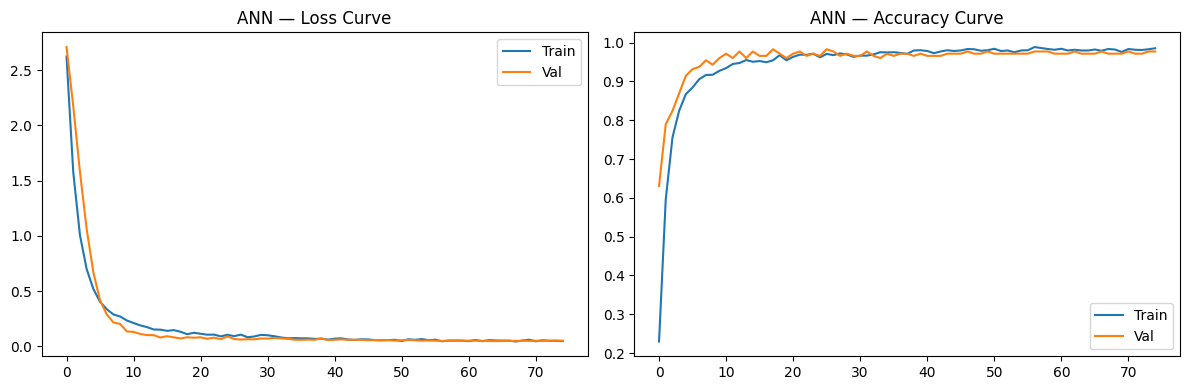


  ANN
  Accuracy : 0.9932
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20


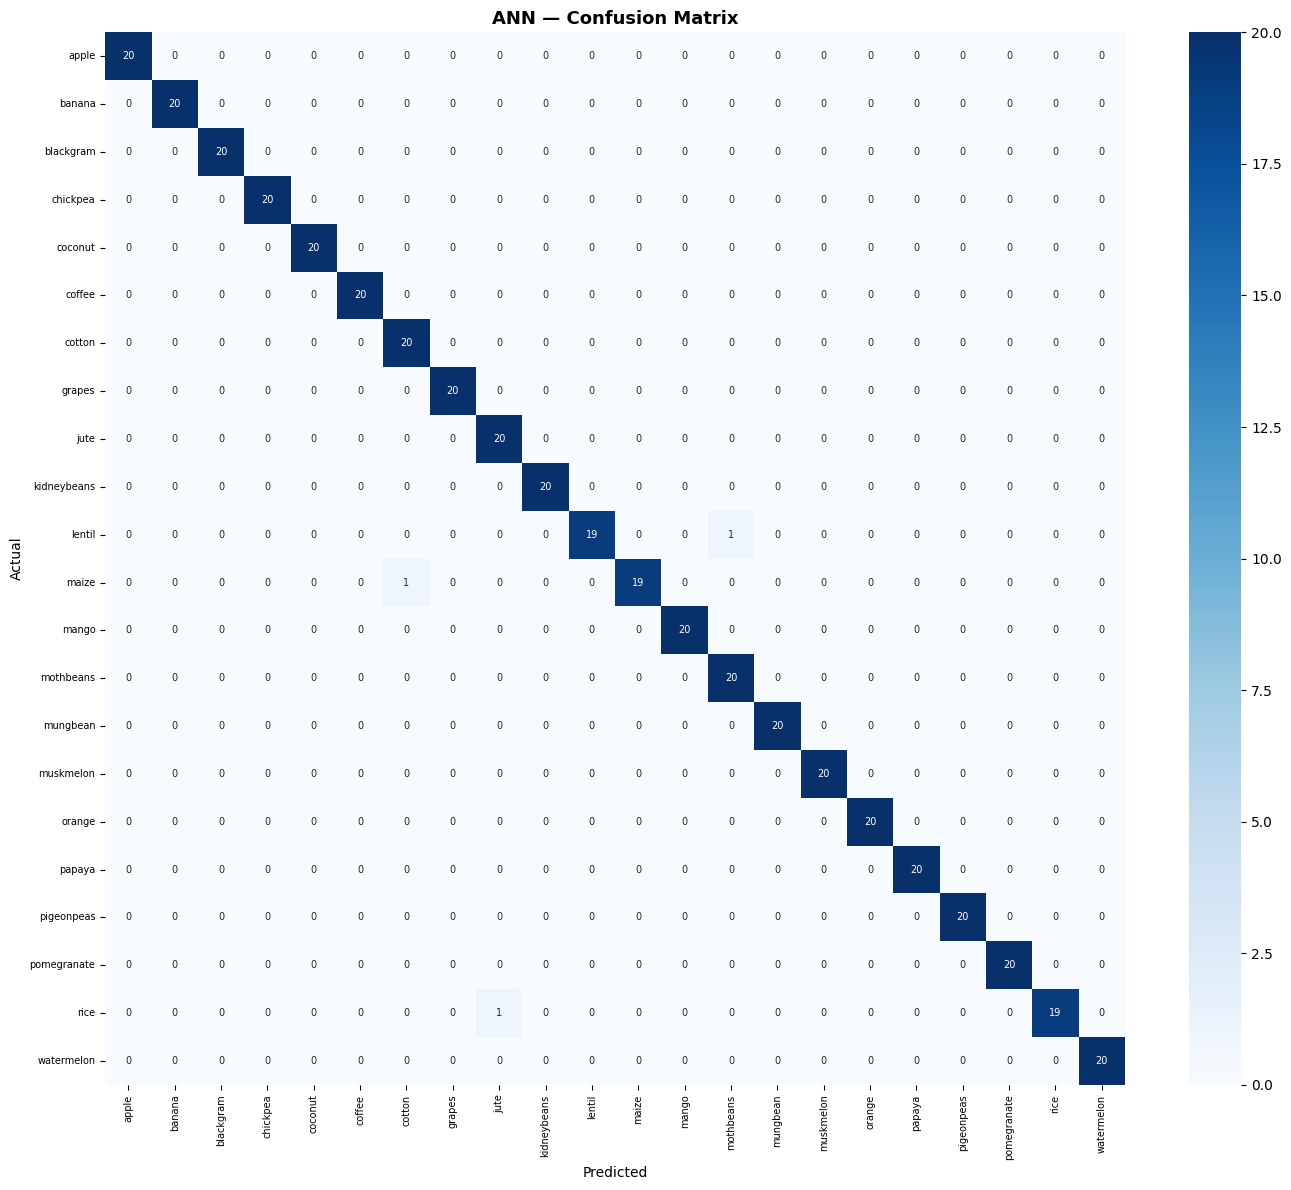

In [16]:
print(" Building ANN...")

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

def build_ann(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32,  activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer = 'adam',
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model

ann = build_ann(X_train_sc.shape[1], NUM_CLASSES)
ann.summary()

es1  = EarlyStopping(patience=10,
                     restore_best_weights=True, verbose=0)
rlr1 = ReduceLROnPlateau(patience=5, factor=0.5, verbose=0)

h_ann = ann.fit(
    X_train_sc, y_train_cat,
    validation_data = (X_val_sc, y_val_cat),
    epochs     = 100,
    batch_size = 32,
    callbacks  = [es1, rlr1],
    verbose    = 1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_ann.history['loss'],     label='Train')
axes[0].plot(h_ann.history['val_loss'], label='Val')
axes[0].set_title('ANN — Loss Curve')
axes[0].legend()

axes[1].plot(h_ann.history['accuracy'],     label='Train')
axes[1].plot(h_ann.history['val_accuracy'], label='Val')
axes[1].set_title('ANN — Accuracy Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

ann_pred, ann_prob = evaluate(
    'ANN', ann,
    X_train_sc, X_test_sc,
    y_train, y_test,
    is_nn=True
)

 Building DNN (Deep)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,222 (715.71 KB)

 Trainable params: 181,302 (708.21 KB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.2449 - loss: 2.5424 - val_accuracy: 0.4091 - val_loss: 2.8028 - learning_rate: 0.0010
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5985 - loss: 1.5179 - val_accuracy: 0.5739 - val_loss: 2.3509 - learning_rate: 0.0010
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7475 - loss: 0.9769 - val_accuracy: 0.6193 - val_loss: 1.8235 - learning_rate: 0.0010
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7929 - loss: 0.7191 - val_accuracy: 0.7386 - val_loss: 1.2891 - learning_rate: 0.0010
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8542 - loss: 0.5264 - val_accuracy: 0.8068 - val_loss: 0.8480 - learning_rate: 0.0010
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8712 - loss: 0.4285 - val_accuracy: 0.8807 - val_loss: 0.5025 - learning_rate: 0.0010
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8927 - loss: 0.3684 - val_

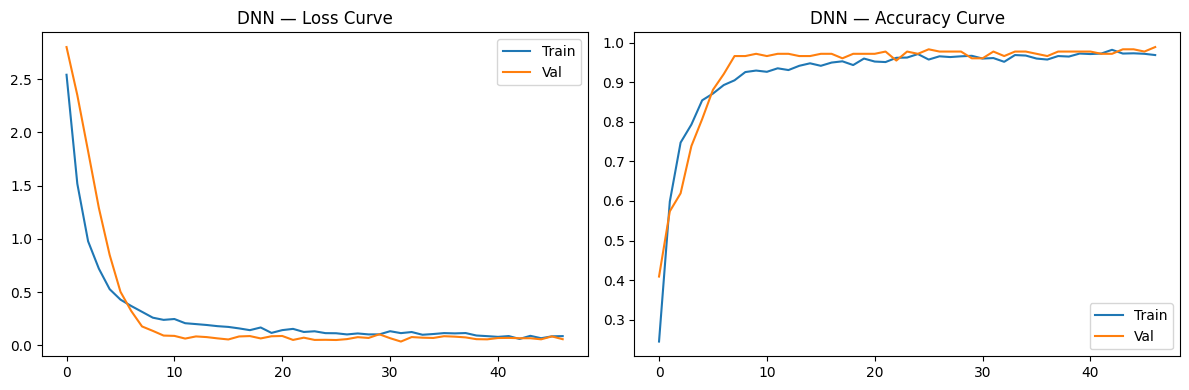


  DNN
  Accuracy : 0.9864
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20


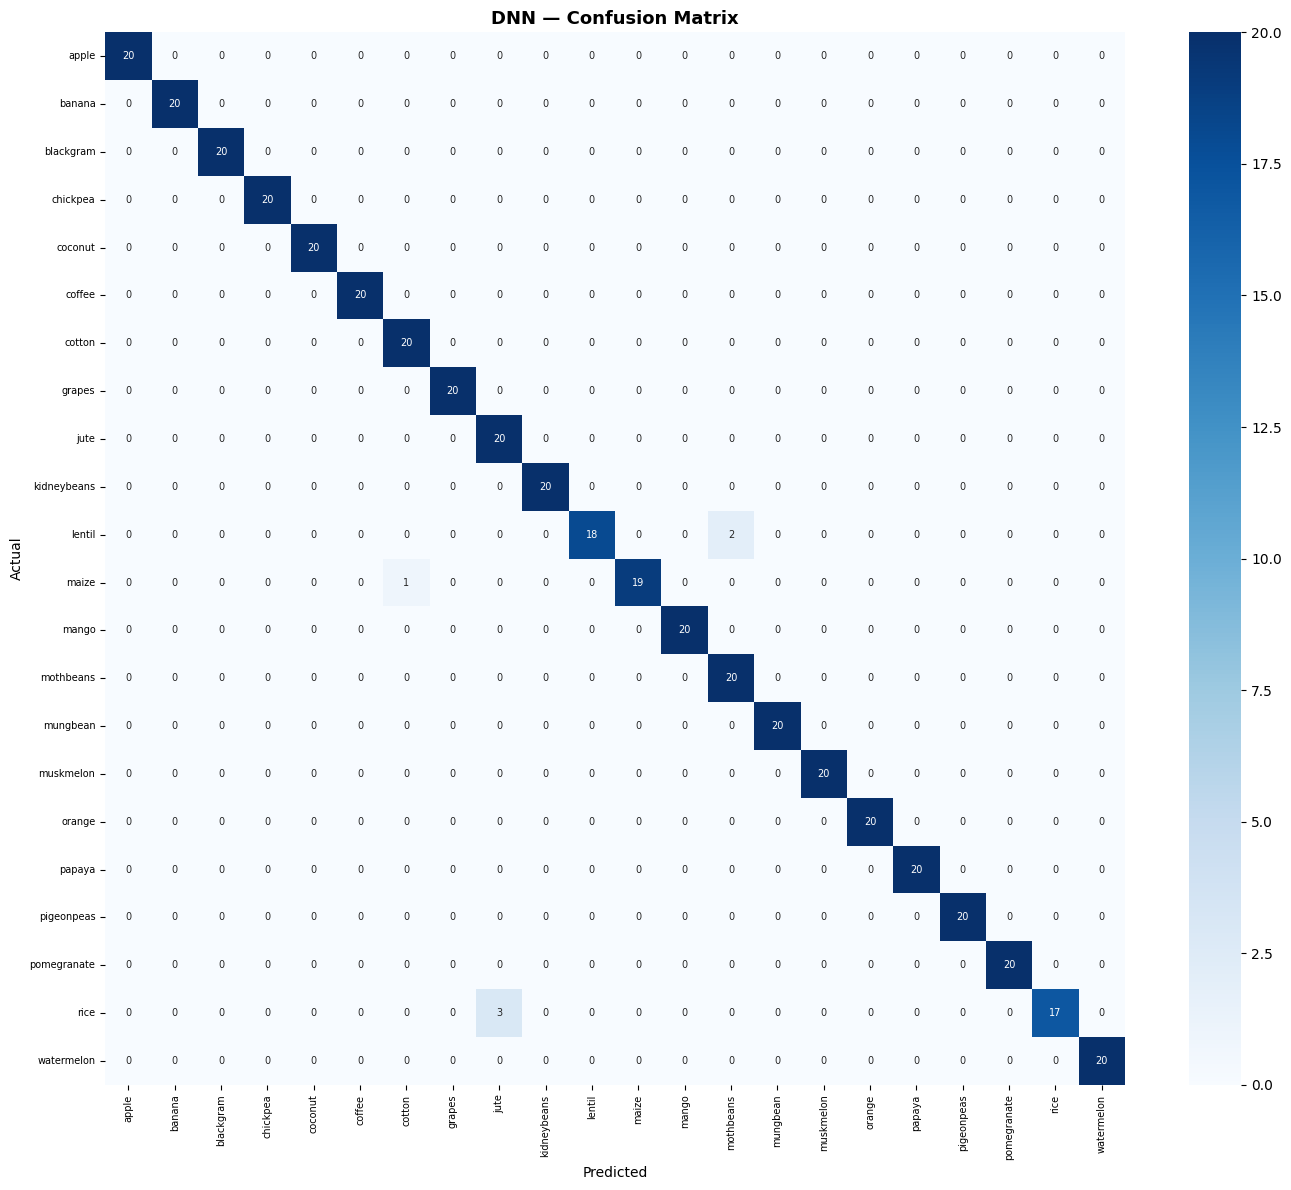

In [17]:
print(" Building DNN (Deep)...")

def build_dnn(input_dim, num_classes):
    model = Sequential([
        # Block 1
        Dense(512, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),
        # Block 2
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.35),
        # Block 3
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        # Block 4
        Dense(64,  activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        # Block 5
        Dense(32,  activation='relu'),
        # Output
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model

dnn = build_dnn(X_train_sc.shape[1], NUM_CLASSES)
dnn.summary()

es2  = EarlyStopping(patience=15,
                     restore_best_weights=True, verbose=0)
rlr2 = ReduceLROnPlateau(patience=7, factor=0.5, verbose=0)

h_dnn = dnn.fit(
    X_train_sc, y_train_cat,
    validation_data = (X_val_sc, y_val_cat),
    epochs     = 150,
    batch_size = 32,
    callbacks  = [es2, rlr2],
    verbose    = 1
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_dnn.history['loss'],     label='Train')
axes[0].plot(h_dnn.history['val_loss'], label='Val')
axes[0].set_title('DNN — Loss Curve')
axes[0].legend()

axes[1].plot(h_dnn.history['accuracy'],     label='Train')
axes[1].plot(h_dnn.history['val_accuracy'], label='Val')
axes[1].set_title('DNN — Accuracy Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

dnn_pred, dnn_prob = evaluate(
    'DNN', dnn,
    X_train_sc, X_test_sc,
    y_train, y_test,
    is_nn=True
)

In [18]:
print(" SHAP Analysis (Random Forest)...")

explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_test_sc)

# SHAP is list of arrays for multi-class
# Stack for summary
shap_mean  = np.abs(np.array(shap_vals)).mean(axis=0).mean(axis=0)
shap_df    = pd.Series(shap_mean, index=features).sort_values(ascending=False)

print("\nGlobal SHAP Feature Importance (mean |SHAP| across classes):")
print(shap_df)

# Bar plot
plt.figure(figsize=(8, 5))
shap_df.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('SHAP — Global Feature Importance (RF)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Mean |SHAP value|')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Summary plot for one class (e.g. class 0)
print("\nSHAP Summary Plot — Class:", le.classes_[0])
shap.summary_plot(shap_vals[0],
                  X_test_sc,
                  feature_names=features,
                  max_display=7,
                  show=True)

 SHAP Analysis (Random Forest)...


ValueError: Length of values (22) does not match length of index (7)

In [ ]:
print(" 5-Fold Stratified Cross-Validation...")

cv_models = {
    'Random Forest' : rf,
    'XGBoost'       : xgb,
    'LightGBM'      : lgb,
}

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  {name:<20} {scores.mean():.4f} ± {scores.std():.4f}")

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(),
            labels     = cv_results.keys(),
            patch_artist=True,
            boxprops   = dict(facecolor='steelblue', alpha=0.6))
plt.ylabel('Accuracy')
plt.title('5-Fold CV Accuracy Distribution',
          fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


 Model Comparison:
               Accuracy
Random Forest    0.9977
ANN              0.9932
LightGBM         0.9909
XGBoost          0.9886
DNN              0.9864


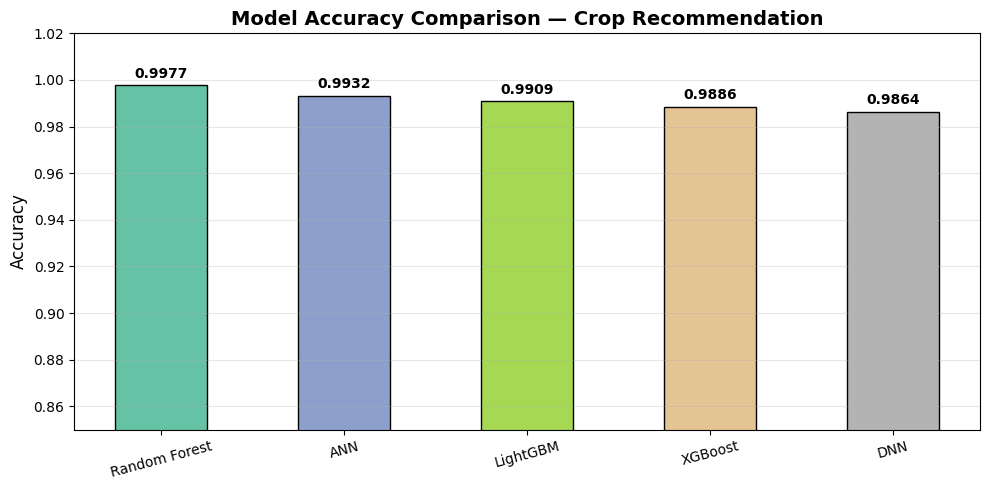

In [19]:
results_df = (pd.DataFrame(results).T
               .sort_values('Accuracy', ascending=False))

print("\n Model Comparison:")

print(results_df.to_string())

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df.index,
               results_df['Accuracy'],
               color=plt.cm.Set2(np.linspace(0, 1,
                                  len(results_df))),
               edgecolor='black', width=0.5)

# Value labels on bars
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

plt.ylim(0.85, 1.02)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison — Crop Recommendation',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

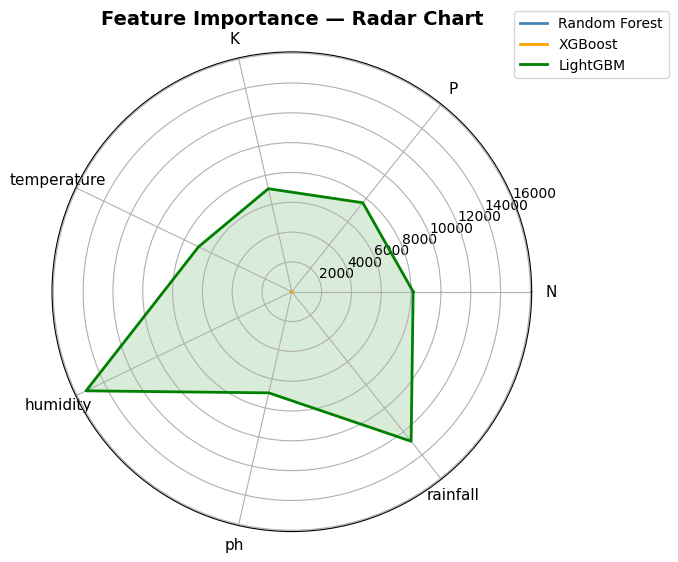

In [20]:
from matplotlib.patches import FancyArrowPatch

labels  = features
n_feat  = len(labels)
angles  = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

model_imp = {
    'Random Forest' : (feat_imp_rf.reindex(features).values.tolist()),
    'XGBoost'       : (feat_imp_xgb.reindex(features).values.tolist()),
    'LightGBM'      : (feat_imp_lgb.reindex(features).values.tolist()),
}
colors_radar = ['steelblue','orange','green']

fig, ax = plt.subplots(figsize=(7, 7),
                        subplot_kw=dict(polar=True))

for (name, vals), color in zip(model_imp.items(), colors_radar):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, color=color, lw=2, label=name)
    ax.fill(angles, vals_plot, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Feature Importance — Radar Chart',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [21]:
print(" CROP RECOMMENDATION DEMO")

def recommend_crop(N, P, K, temperature,
                   humidity, ph, rainfall,
                   scaler_, rf_model, xgb_model,
                   lgb_model, dnn_model, le_):

    inp = np.array([[N, P, K, temperature,
                     humidity, ph, rainfall]])
    inp_sc = scaler_.transform(inp)

    # Predictions
    rf_p   = rf_model.predict_proba(inp_sc)[0]
    xgb_p  = xgb_model.predict_proba(inp_sc)[0]
    lgb_p  = lgb_model.predict_proba(inp_sc)[0]
    dnn_p  = dnn_model.predict(inp_sc, verbose=0)[0]

    # Ensemble average
    avg_p  = (rf_p + xgb_p + lgb_p + dnn_p) / 4
    pred   = le_.classes_[np.argmax(avg_p)]
    conf   = np.max(avg_p)

    # Top 3 crops
    top3_idx   = avg_p.argsort()[-3:][::-1]
    top3_crops = [(le_.classes_[i], avg_p[i]) for i in top3_idx]

    print(f"\n Input Conditions:")
    print(f"   N={N}, P={P}, K={K}")
    print(f"   Temperature={temperature}°C")
    print(f"   Humidity={humidity}%")
    print(f"   pH={ph}")
    print(f"   Rainfall={rainfall}mm")

    print(f"\n Recommended Crop : {pred.upper()}")
    print(f"   Confidence        : {conf*100:.1f}%")
    print(f"\n Top 3 Crops:")
    for rank, (crop, prob) in enumerate(top3_crops, 1):
        bar = '█' * int(prob * 30)
        print(f"   {rank}. {crop:<15} {prob*100:5.1f}%  {bar}")

    return pred

# Test Case 1 — Rice conditions
print("\n" + "─"*55)
print("Test 1 — Rice-like conditions")
recommend_crop(90, 42, 43, 20.9, 82.0, 6.5, 202.9,
               scaler, rf, xgb, lgb, dnn, le)

# Test Case 2 — Apple conditions
print("\n" + "─"*55)
print("Test 2 — Apple-like conditions")
recommend_crop(21, 134, 200, 21.0, 92.0, 6.0, 112.0,
               scaler, rf, xgb, lgb, dnn, le)

# Test Case 3 — Cotton conditions
print("\n" + "─"*55)
print("Test 3 — Cotton-like conditions")
recommend_crop(117, 32, 34, 23.6, 79.8, 6.5, 72.5,
               scaler, rf, xgb, lgb, dnn, le)

# Test Case 4 — Mango conditions
print("\n" + "─"*55)
print("Test 4 — Mango-like conditions")
recommend_crop(20, 27, 30, 30.0, 50.0, 6.0, 95.0,
               scaler, rf, xgb, lgb, dnn, le)

 CROP RECOMMENDATION DEMO

───────────────────────────────────────────────────────
Test 1 — Rice-like conditions

 Input Conditions:
   N=90, P=42, K=43
   Temperature=20.9°C
   Humidity=82.0%
   pH=6.5
   Rainfall=202.9mm

 Recommended Crop : RICE
   Confidence        : 95.2%

 Top 3 Crops:
   1. rice             95.2%  ████████████████████████████
   2. jute              4.7%  █
   3. coffee            0.0%  

───────────────────────────────────────────────────────
Test 2 — Apple-like conditions

 Input Conditions:
   N=21, P=134, K=200
   Temperature=21.0°C
   Humidity=92.0%
   pH=6.0
   Rainfall=112.0mm

 Recommended Crop : APPLE
   Confidence        : 98.5%

 Top 3 Crops:
   1. apple            98.5%  █████████████████████████████
   2. grapes            1.3%  
   3. chickpea          0.1%  

───────────────────────────────────────────────────────
Test 3 — Cotton-like conditions

 Input Conditions:
   N=117, P=32, K=34
   Temperature=23.6°C
   Humidity=79.8%
   pH=6.5
   Rainfall=

'mango'

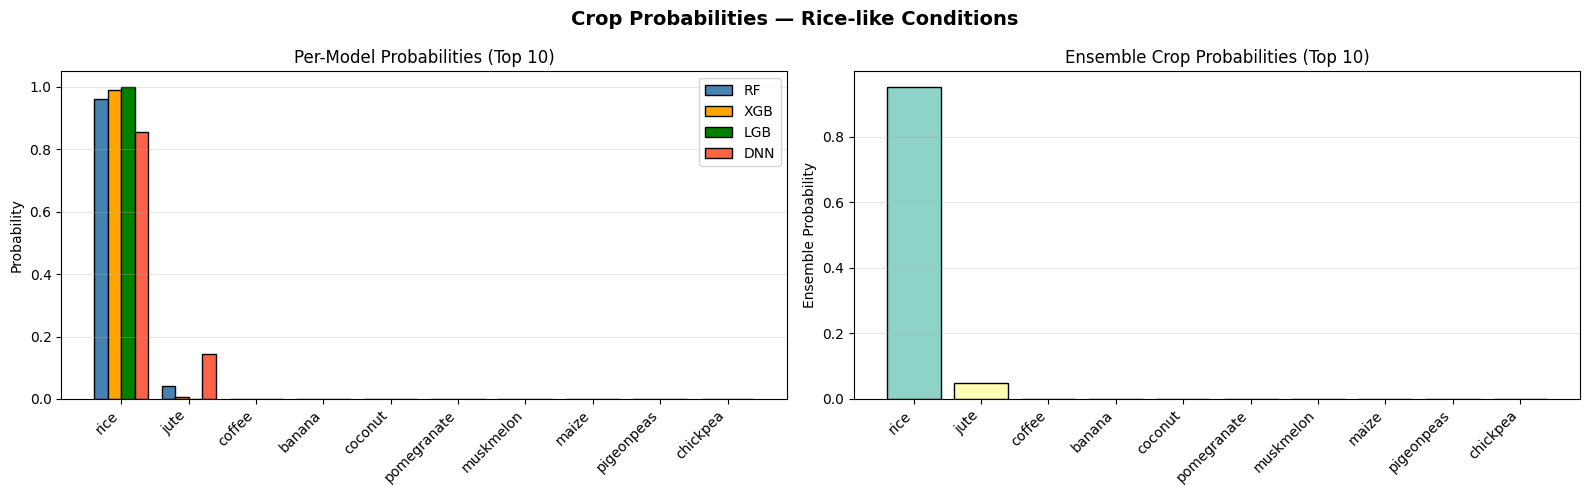

In [22]:
def plot_crop_probs(N, P, K, temperature,
                   humidity, ph, rainfall,
                   scaler_, rf_m, xgb_m, lgb_m, dnn_m, le_,
                   title='Crop Probability'):

    inp    = np.array([[N, P, K, temperature,
                        humidity, ph, rainfall]])
    inp_sc = scaler_.transform(inp)

    rf_p   = rf_m.predict_proba(inp_sc)[0]
    xgb_p  = xgb_m.predict_proba(inp_sc)[0]
    lgb_p  = lgb_m.predict_proba(inp_sc)[0]
    dnn_p  = dnn_m.predict(inp_sc, verbose=0)[0]
    avg_p  = (rf_p + xgb_p + lgb_p + dnn_p) / 4

    # Top 10 only
    top10_idx  = avg_p.argsort()[-10:][::-1]
    top10_prob = avg_p[top10_idx]
    top10_name = le_.classes_[top10_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Bar — all models
    x  = np.arange(len(top10_name))
    w  = 0.2
    axes[0].bar(x - 1.5*w, rf_p[top10_idx],
                width=w, label='RF',  color='steelblue', edgecolor='black')
    axes[0].bar(x - 0.5*w, xgb_p[top10_idx],
                width=w, label='XGB', color='orange',    edgecolor='black')
    axes[0].bar(x + 0.5*w, lgb_p[top10_idx],
                width=w, label='LGB', color='green',     edgecolor='black')
    axes[0].bar(x + 1.5*w, dnn_p[top10_idx],
                width=w, label='DNN', color='tomato',    edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top10_name, rotation=45, ha='right')
    axes[0].set_ylabel('Probability')
    axes[0].set_title('Per-Model Probabilities (Top 10)')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Bar — ensemble
    bar_colors = plt.cm.Set3(np.linspace(0, 1, len(top10_name)))
    axes[1].bar(top10_name, top10_prob,
                color=bar_colors, edgecolor='black')
    axes[1].set_xticklabels(top10_name, rotation=45, ha='right')
    axes[1].set_ylabel('Ensemble Probability')
    axes[1].set_title('Ensemble Crop Probabilities (Top 10)')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize prediction for test case 1
plot_crop_probs(90, 42, 43, 20.9, 82.0, 6.5, 202.9,
                scaler, rf, xgb, lgb, dnn, le,
                title='Crop Probabilities — Rice-like Conditions')

In [23]:
print(" FINAL MODEL LEADERBOARD")


final_df = (pd.DataFrame(results).T
             .sort_values('Accuracy', ascending=False))
final_df['Accuracy'] = final_df['Accuracy'].map('{:.4f}'.format)
print(final_df.to_string())

res_num  = pd.DataFrame(results).T
best_mdl = res_num['Accuracy'].idxmax()
best_acc = res_num['Accuracy'].max()


print(f"   Best Model    : {best_mdl}")
print(f"   Best Accuracy : {best_acc:.4f}")

print("\n Smart Crop Recommendation Project Complete!")

 FINAL MODEL LEADERBOARD
              Accuracy
Random Forest   0.9977
ANN             0.9932
LightGBM        0.9909
XGBoost         0.9886
DNN             0.9864
   Best Model    : Random Forest
   Best Accuracy : 0.9977

 Smart Crop Recommendation Project Complete!
